## Basic Dataset Understanding and Analysis

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# 1) Basic Exploratation

print("Dataset Shape:", df.shape)

print("\n Dataset Info:")
print("-" * 40)
df.info()

print("\n")
df.describe(include="all")

Dataset Shape: (2484, 4)

 Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB




,ID,Resume_str,Resume_html,Category
count,2.484000e+03,2484,2484,2484
unique,NaN,2482,2482,24
top,NaN,STOREKEEPER II Professional Sum...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY
freq,NaN,2,2,120
mean,3.182616e+07,NaN,NaN,NaN
std,2.145735e+07,NaN,NaN,NaN
min,3.547447e+06,NaN,NaN,NaN
25%,1.754430e+07,NaN,NaN,NaN
50%,2.521031e+07,NaN,NaN,NaN
75%,3.611444e+07,NaN,NaN,NaN


In [4]:
# 2) Check Missing Values

print("\nMissing Values:")
print("-" * 20)
print(df.isnull().sum())


Missing Values:
--------------------
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [6]:
# 3) Duplicate Analysis

print("Duplicates:", df.duplicated().sum())

print("\nID Duplicates:", df["ID"].duplicated().sum())

print("\nResume_str Duplicates:",df["Resume_str"].duplicated().sum())

print("\nResume_html Duplicates:", df["Resume_html"].duplicated().sum())

Duplicates: 0

ID Duplicates: 0

Resume_str Duplicates: 2

Resume_html Duplicates: 2


In [7]:
# 4) Category Distribution

print("Category Distribution:")
print("-" * 30)
df["Category"].value_counts()

Category Distribution:
------------------------------


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [8]:
# 5) Resume Length Analysis

# Create Character Length Column
df["char_length"] = df["Resume_str"].apply(len)

# Create Word Length Column
df["word_length"] = df["Resume_str"].apply(lambda x: len(x.split()))

In [9]:
df.head()

,ID,Resume_str,Resume_html,Category,char_length,word_length
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,5442,674
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,5572,708
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,7720,1017
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,2855,379
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,9172,1206


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
 4   char_length  2484 non-null   int64 
 5   word_length  2484 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 116.6+ KB


In [11]:
# 6) Explore Sample Resumes
df.iloc[0]["Resume_str"]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

In [12]:
df.iloc[100]["Resume_str"]

'         HR BENEFITS/LEAVE COORDINATOR       Summary    13 years of Human Resources experience and 27 years of administrative experience working in various settings\n*Professional, detail-oriented, excellent time-management skills, team player, open and honest communicator, effective at maintaining confidentiality and multi-tasker.      Skills        Proficient in all Microsoft applications and HRIS systems (Banner, PeopleAdmin, Personnel Management Information (PMIS) System and Benefits Eligibility System (BES), VRS Navigator (VNAV))            Experience     December 2016   to   Current     Company Name   City  ,   State     HR Benefits/Leave Coordinator        Provide consultation and assistance for all employee benefits.  Assist Retirement/Benefits Manager in counseling employees on retirements as well as generate retirement calculations.  Assist Retirement/Benefits Manager with retirement trainings.  Promote and coordinate all aspects of the Highlander Wellness Watch program.  Ad

In [13]:
df.iloc[1000]["Resume_str"]

"         SALES       Summary    Over 17 years of sales and operations management experience in specialty and big-box retail and 4 years sales experience in the automotive sector.  Experienced in hiring, training, supervision, and coaching.  Proven skills in operations and human resource management, planning, negotiating, organizing and overseeing projects, and events. Committed to the highest work ethic and attainment of organizational goals and objectives.      Highlights          Excellent interpersonal and coaching skills  Sales leadership development  Performance metrics  Detail-oriented   Procedure development    Employee engagement  Conflict resolution      On-boarding and training  Recruiting  Performance coaching and counseling   Operations management    Human resources management    P&L management   Powerful negotiator              Accomplishments       Drove store ranking from 297 in company to top 10 in less than 6 months of taking over store    Increased year-over-year sal

In [14]:
df.iloc[1500]["Resume_str"]

"         FINANCE MANAGER           Professional Summary    To attain a responsible position in an organization of repute where I can utilize my accounting expertise to prepare fair and accurate financial documents for the organization.      Core Qualifications        Well versed with Windows Operating System, Microsoft Office, Internet Operations, Oracle ERP, SAP & Tally \nDate :          Signature :            Experience      Finance Manager    January 2012       Company Name   －   City        RICOH India Ltd is 73.6% Owned subsidiary company of Japan base RICOH Co.  Ltd.  They are basically deals with manufacturing and installing office automation equipment like multifunctional printer, copier, fax etc.  They have 14 branches and 230 dealers in all over India.  with average sales revenue 10 billion.  New Delhi/NCR  as a Senior Finance Executive( from 20th Sept'12 to 16th Feb'15) Key Responsibility: Budgeting & forecasting as well as critical point analysis.  IRR & NPV Calculation fo

In [15]:
df.iloc[2000]["Resume_str"]

'         ASSISTANT PROJECT MANAGER/DESIGN BUILD CONSTRUCTION COORDINATOR       Summary     Highly motivated Civil Engineer with 16 years of experience working for one of North America\'s largest and most respected construction and engineering organizations with revenues of more than $11 billion and consistently ranking among the top five contractors by Engineering News-Record.   My experience with Kiewit has prepared me to successfully plan and execute projects while promoting safety, quality, schedule, and cost performance. My career experience ranges from construction design coordinator on a multi billion dollar design build project, to on-site project engineering and project management for self-performing heavy civil construction work ranging from $545 million to $3.1 million dollars. Excellent communicator skilled in construction means and methods, cost controls, scheduling, claims analysis and contract administration.   As the Field Engineer and Project Controls Manager on one of

In [16]:
# 7) HTML Analysis
print(df["Resume_html"])

0       <div class="fontsize fontface vmargins hmargin...
1       <div class="fontsize fontface vmargins hmargin...
2       <div class="fontsize fontface vmargins hmargin...
3       <div class="fontsize fontface vmargins hmargin...
4       <div class="fontsize fontface vmargins hmargin...
                              ...                        
2479    <div class="fontsize fontface vmargins hmargin...
2480    <div class="fontsize fontface vmargins hmargin...
2481    <div class="fontsize fontface vmargins hmargin...
2482    <div class="fontsize fontface vmargins hmargin...
2483    <div class="fontsize fontface vmargins hmargin...
Name: Resume_html, Length: 2484, dtype: object


In [17]:
# 8) Email Detection
import re

# Regular expression for email addresses
email_pattern = r"[A-Za-z0-9._%+-]+@(gmail|outlook|yahoo)\.[A-Za-z.]{2,}"

# Search the entire Dataset
mask = df.astype(str).apply(
    lambda col: col.str.contains(email_pattern, case=False, regex=True, na=False)
).any(axis=1)

matching_rows = df[mask]

if not matching_rows.empty:
    print(f"Found {len(matching_rows)} row(s) containing Gmail, Outlook, or Yahoo email addresses.")
    print(matching_rows)
else:
    print("No Gmail, Outlook, or Yahoo email addresses found.")

Found 6 row(s) containing Gmail, Outlook, or Yahoo email addresses.
            ID                                         Resume_str  \
386   23398843           TEACHER          Facebook:    Lamaest...   
1202  22571461           STAFF CONSULTANT       Summary    Exp...   
1576  59818742           AN ACCOUNT CUM FINANCE MANAGER       ...   
1649  12059610           SHOE DEPT. LEAD SUPERVISOR           ...   
1741  90280583           DIRECTOR OF ENGINEERING         Summa...   
1921  18635654           GENERAL ACCOUNTANT       Professional...   

                                            Resume_html     Category  \
386   <div class="fontsize fontface vmargins hmargin...      TEACHER   
1202  <div class="fontsize fontface vmargins hmargin...   CONSULTANT   
1576  <div class="fontsize fontface vmargins hmargin...      FINANCE   
1649  <div class="fontsize fontface vmargins hmargin...      APPAREL   
1741  <div class="fontsize fontface vmargins hmargin...  ENGINEERING   
1921  <div class

In [18]:
# 9) Phone number Detection

# Regular expression for common phone number formats
phone_pattern = r"(\+91[\s-]?)?[6-9]\d{9}|\(\d{3}\)\s?\d{3}[-\s]?\d{4}"

# Search the entire Dataset
mask = df.astype(str).apply(
    lambda col: col.str.contains(phone_pattern, case=False, regex=True, na=False)
).any(axis=1)

matching_rows = df[mask]

if not matching_rows.empty:
    print(f"Found {len(matching_rows)} row(s) containing phone number(s).")
    print(matching_rows)
else:
    print("No phone numbers found.")

Found 65 row(s) containing phone number(s).
            ID                                         Resume_str  \
77    44476983           HR BUSINESS PARTNER       Summary    ...   
81    24508725           FIELD HR ASSOCIATE           Summary ...   
99    19336728           HR ASSISTANT INTERN       Summary    ...   
129   38565119             INDEPENDENT DESIGNER         Profes...   
194   18835363             PROGRAM MANAGER & DESIGNER         ...   
...        ...                                                ...   
2392  81588968           SUPERINTENDENT II           Summary  ...   
2393  18268860           QUALITY CONTROL INSPECTOR       Summa...   
2452  11752500           ELECTRICIAN         Professional Summ...   
2471  12239749           SPECIALIST OF INFANTRY       Professi...   
2473  17008356           ACCOUNT EXECUTIVE         Professiona...   

                                            Resume_html  Category  \
77    <div class="RNA skn-mdl1 fontsize fontface vma...   

In [19]:
# 10) URL Detection

# Regular expression for LinkedIn, GitHub, and common portfolio URLs
url_pattern = r"(linkedin\.com|github\.com|gitlab\.com|portfolio|behance\.net|dribbble\.com|medium\.com|https?://|www\.)"

# Search only the Resume_str column
mask = df["Resume_str"].str.contains(
    url_pattern,
    case=False,
    regex=True,
    na=False
)

matching_rows = df[mask]

if not matching_rows.empty:
    print(f"Found {len(matching_rows)} row(s) containing URLs or portfolio links.")
    print(matching_rows[["Resume_str"]])   # Print only the Resume_str column
else:
    print("No URLs or portfolio links found.")

Found 280 row(s) containing URLs or portfolio links.
                                             Resume_str
36             HR GENERALIST           Summary     H...
52             HR GENERALIST       Professional Summ...
78             ASSISTANT MANAGER - HR            www...
81             FIELD HR ASSOCIATE           Summary ...
88             REGIONAL HR DEPUTY MANAGER       Summ...
...                                                 ...
2423           OPERATION MANAGER            www.link...
2447           PURCHASER / PRODUCTION COORDINATOR   ...
2448           SUPERVISOR       Summary    I was a s...
2466           MANAGEMENT AND PROGRAM ANALYSIS      ...
2475           SENIOR LEAD TECHNOLOGIST EDITOR      ...

[280 rows x 1 columns]


## Vocabulary Analysis

In [21]:
# Step 1 — Create a Single Text Corpus - Combine all resumes into one large text corpus

corpus = " ".join(df["Resume_str"])

print(type(corpus))
print("\nTotal Characters:", len(corpus))

<class 'str'>

Total Characters: 15640030


In [23]:
# Step 2 — Count Total Words

words = corpus.split()

print("Total Words:", len(words))

Total Words: 2015333


In [24]:
# Step 3 — Count Unique Words (Vocabulary Size)

vocabulary = set(words)

print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 111423


In [25]:
# Step 4 — Most Frequent Words

from collections import Counter

word_counts = Counter(words)

word_counts.most_common(30)

[('and', 122399),
 ('to', 53429),
 ('of', 42633),
 ('the', 35494),
 ('for', 28105),
 ('in', 27020),
 ('with', 21462),
 (',', 18910),
 ('a', 15613),
 ('State', 15278),
 ('City', 14889),
 ('Company', 11810),
 ('Name', 11602),
 ('on', 9968),
 ('as', 9950),
 ('all', 8452),
 ('－', 6890),
 ('by', 6687),
 ('customer', 5796),
 ('-', 5599),
 ('new', 5436),
 ('&', 4762),
 ('management', 4485),
 ('that', 4425),
 ('sales', 4366),
 ('I', 4263),
 ('team', 4038),
 ('business', 3982),
 ('or', 3978),
 ('from', 3936)]

In [27]:
# Step 5 — Convert to DataFrame

freq_df = pd.DataFrame(
    word_counts.most_common(30),
    columns=["Word", "Frequency"]
)

freq_df

,Word,Frequency
0,and,122399
1,to,53429
2,of,42633
3,the,35494
4,for,28105
5,in,27020
6,with,21462
7,",",18910
8,a,15613
9,State,15278


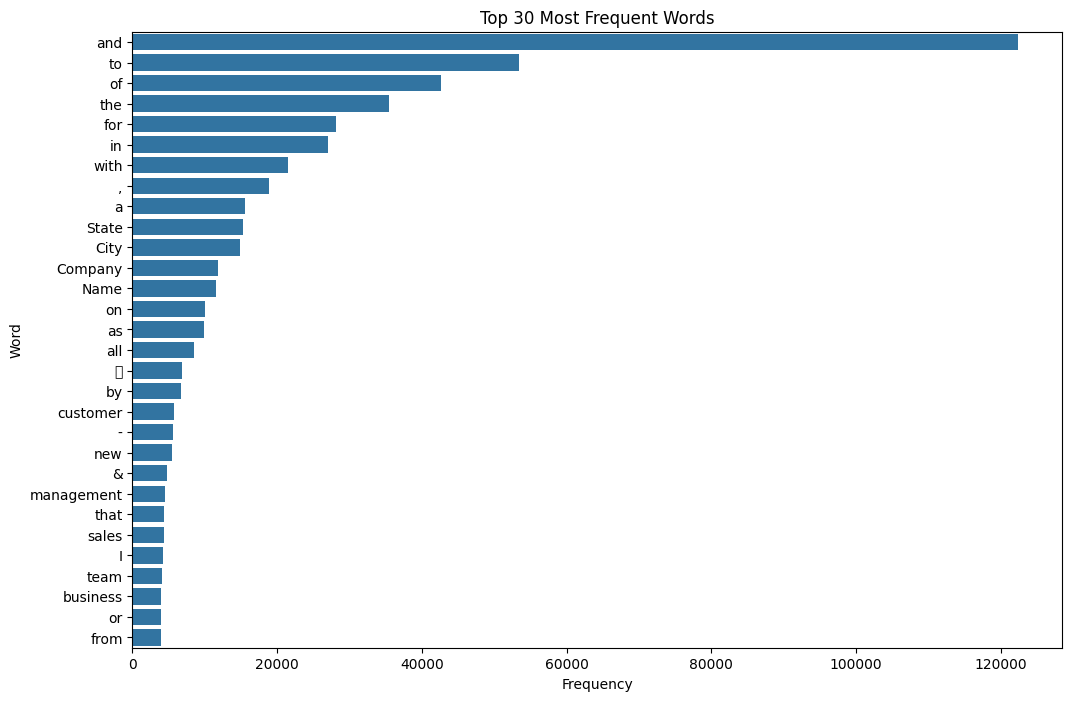

In [28]:
# Step 6 — Plot Top Words

plt.figure(figsize=(12,8))

sns.barplot(
    data=freq_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 30 Most Frequent Words")
plt.show()

In [29]:
# 1. Check specific technical skills
skills = [
    "Python", "python",
    "SQL", "sql",
    "Java", "java",
    "Machine", "Learning",
    "TensorFlow",
    "AWS",
    "Docker",
    "Flask",
    "NLP",
    "Pandas",
    "NumPy",
    "Excel"
]

for skill in skills:
    print(f"{skill}: {word_counts.get(skill, 0)}")

Python: 31
python: 1
SQL: 369
sql: 5
Java: 87
java: 6
Machine: 58
Learning: 209
TensorFlow: 1
AWS: 37
Docker: 4
Flask: 0
NLP: 0
Pandas: 3
NumPy: 0
Excel: 520


In [30]:
# 2. Check strange tokens
strange_tokens = [
    "\\xa0",
    "\\n",
    "－",
    "•"
]

for token in strange_tokens:
    print(f"{token}: {word_counts.get(token, 0)}")

\xa0: 0
\n: 0
－: 6890
•: 419


In [31]:
# 3. Find the longest and shortest resumes
print("Longest Resume:")
display(df.loc[df["word_length"].idxmax(),
               ["Category", "word_length"]])

print("\nShortest Resume:")
display(df.loc[df["word_length"].idxmin(),
               ["Category", "word_length"]])

Longest Resume:


Category       PUBLIC-RELATIONS
word_length                5190
Name: 2111, dtype: object


Shortest Resume:


Category       BUSINESS-DEVELOPMENT
word_length                       0
Name: 656, dtype: object

In [32]:
df.loc[df["word_length"] == 0,
       ["ID","Category","Resume_str"]]

,ID,Category,Resume_str
656,12632728,BUSINESS-DEVELOPMENT,


In [33]:
print("Number of empty resumes:", (df["word_length"] == 0).sum())

Number of empty resumes: 1


In [34]:
# Remove empty resumes
df = df[df["word_length"] > 0].copy()

# Verify
print(df.shape)

(2483, 6)


In [35]:
# Save the Modified Dataset
df.to_csv("resume_modified.csv", index=False)
print("Modified Dataset Saved Successfully!")

Modified Dataset Saved Successfully!


In [1]:
print(ord("-"))
print(ord("－"))

45
65293
